# Notebook 01 — EDA
## STOP 1 — Dataset Overview
Load data, inspect shape/types/stats, and check target distribution.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_PATH = ROOT / 'data' / 'raw' / 'heart.csv'
CHARTS = ROOT / 'charts'
CHARTS.mkdir(exist_ok=True, parents=True)

df = pd.read_csv(DATA_PATH)
print('shape:', df.shape)
print('dtypes:')
print(df.dtypes)
print('describe:')
print(df.describe())
print('target distribution:')
print(df['HeartDisease'].value_counts())

shape: (918, 12)
dtypes:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object
describe:
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  136.809368   
std      9.432617   18.514154   109.384145    0.423046   25.460334   
min     28.000000    0.000000     0.000000    0.000000   60.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max     77.000000  200.000000   603.000000    1.000000  202.000000   

        

## STOP 2 — Missing Values & Distributions
Check null values and visualize numeric/categorical distributions.

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


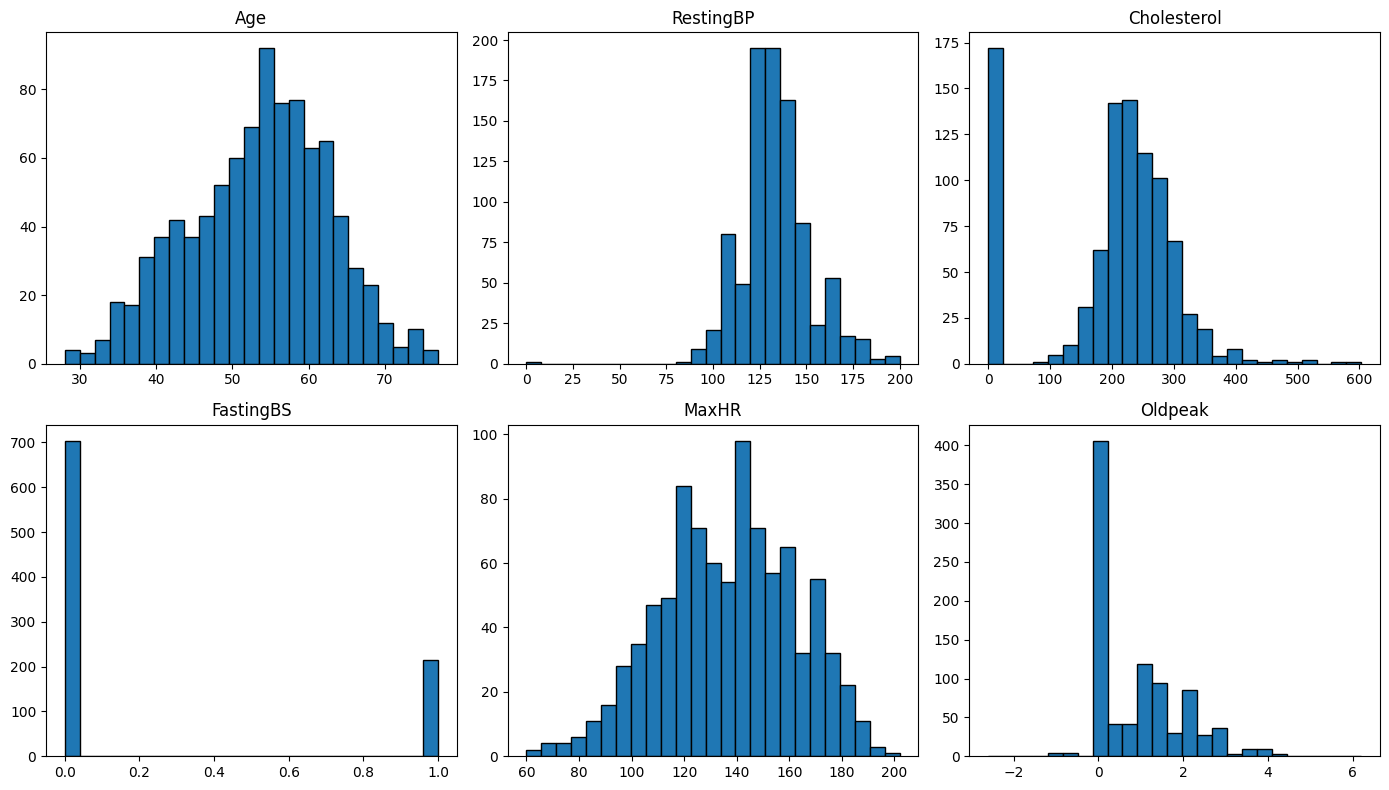

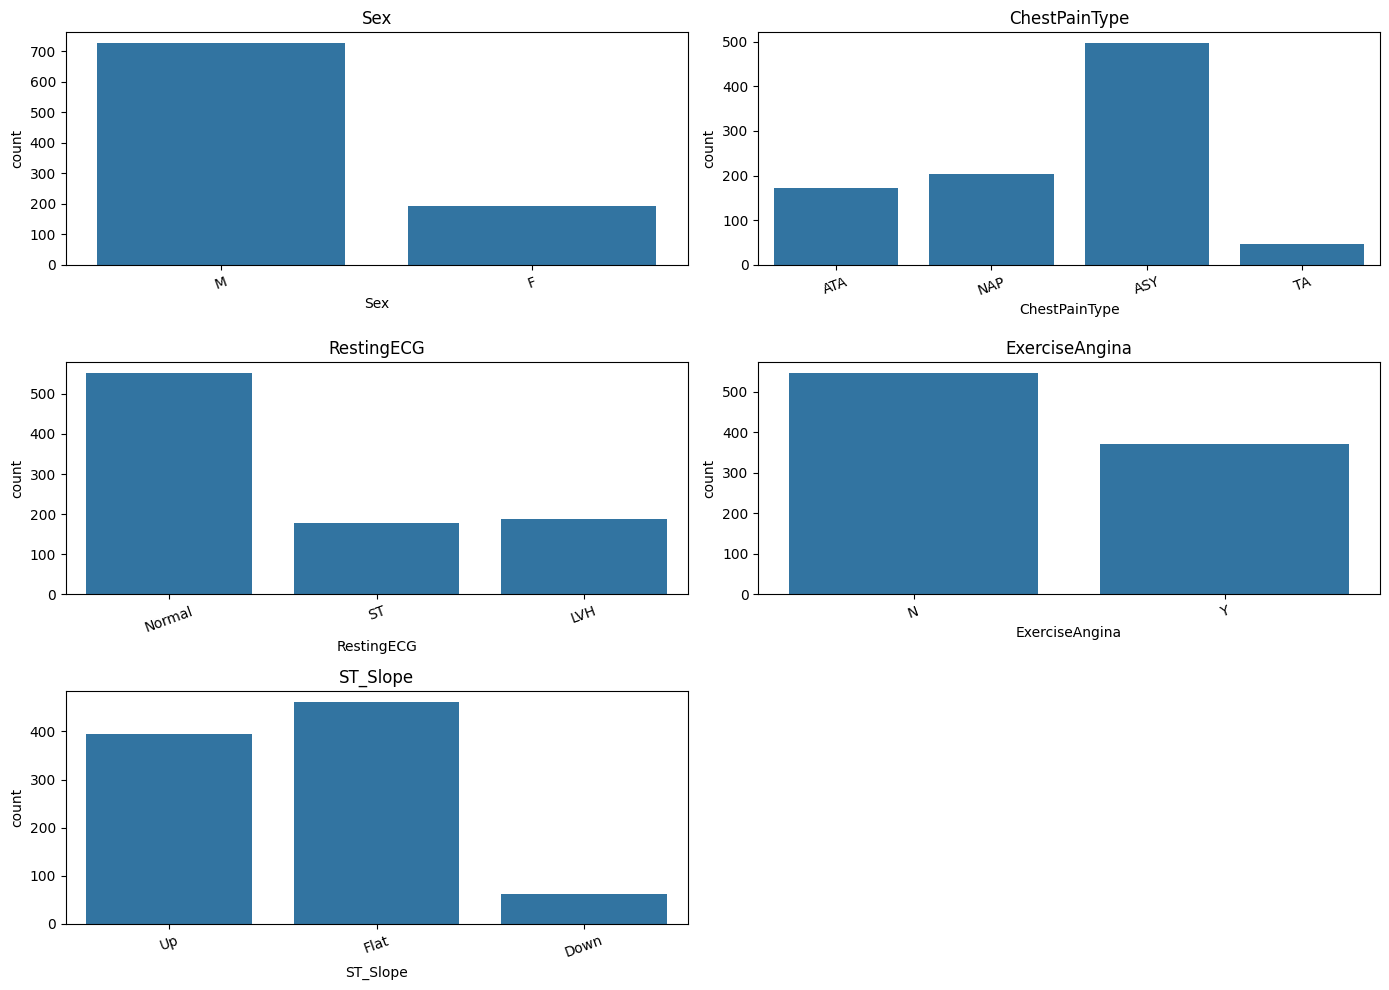

In [3]:
print(df.isnull().sum())

categorical_cols = [c for c in df.columns if df[c].dtype == 'object']
numeric_cols = [c for c in df.columns if c not in categorical_cols + ['HeartDisease']]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    ax.hist(df[col], bins=25, edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.savefig(CHARTS / 'numerical_distributions.png', dpi=180)
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=20)
for i in range(len(categorical_cols), len(axes)):
    axes[i].axis('off')
plt.tight_layout()
plt.savefig(CHARTS / 'categorical_distributions.png', dpi=180)
plt.show()

## STOP 3 — Correlation Analysis
Plot correlation heatmap and show top 3 features correlated with target.

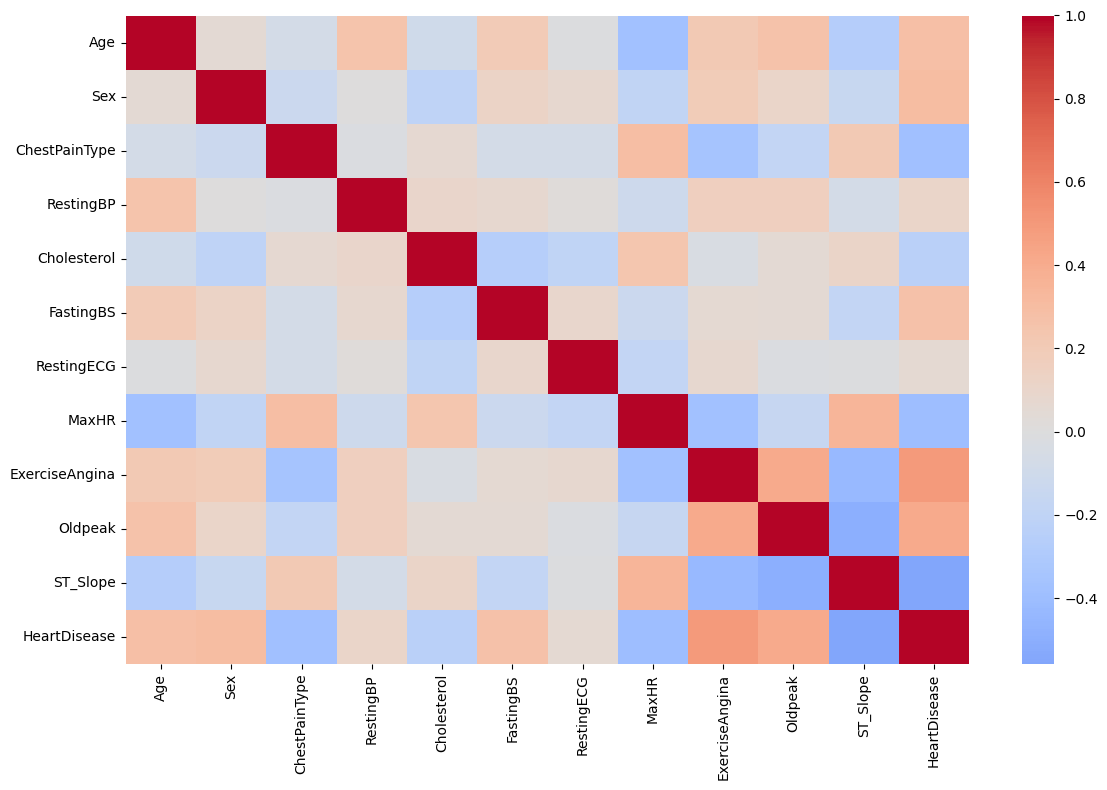

ST_Slope          0.558771
ExerciseAngina    0.494282
Oldpeak           0.403951
Name: HeartDisease, dtype: float64


In [4]:
corr_df = df.copy()
for c in categorical_cols:
    corr_df[c] = corr_df[c].astype('category').cat.codes
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.tight_layout()
plt.savefig(CHARTS / 'correlation_heatmap.png', dpi=180)
plt.show()

print(corr['HeartDisease'].drop('HeartDisease').abs().sort_values(ascending=False).head(3))